# Notebook 07 — Hyperparameter Tuning

## Objective

The objective of this notebook is to improve the performance of the best-performing machine learning model by tuning its hyperparameters.

The tuning process aims to:

- Optimize model performance
- Reduce overfitting
- Improve generalization
- Identify the best parameter combination using Grid Search

The optimized model will be used for the final evaluation in the next notebook.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print("Dataset Loaded Successfully")

print(df.shape)

df.head()

Dataset Loaded Successfully
(101766, 79)


,encounter_id,patient_nbr,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,...,insulin_No,insulin_Steady,insulin_Up,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady
0,2278392,8222157,-3.824600,6,25,1,-1.137649,-0.106517,-0.785398,-1.848268,...,1,0,0,1,0,0,0,0,0,0
1,149190,55629189,-3.197277,1,1,7,-0.467653,0.808384,-0.785398,0.243390,...,0,0,1,1,0,0,0,0,0,0
2,64410,86047875,-2.569954,1,1,7,-0.802651,-1.631351,2.145781,-0.371804,...,1,0,0,1,0,0,0,0,0,0
3,500364,82442376,-1.942632,1,1,7,-0.802651,0.045967,-0.199162,-0.002688,...,0,0,1,1,0,0,0,0,0,0
4,16680,42519267,-1.315309,1,1,7,-1.137649,0.401761,-0.785398,-0.986997,...,0,1,0,1,0,0,0,0,0,0


In [3]:
X = df.drop("readmitted", axis=1)

y = df["readmitted"]

print("Features :", X.shape)

print("Target :", y.shape)

Features : (101766, 78)
Target : (101766,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)

print("Testing Shape :", X_test.shape)

Training Shape : (81412, 78)
Testing Shape : (20354, 78)


In [5]:
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

baseline_prediction = rf.predict(X_test)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_prediction
)

print(f"Baseline Accuracy : {baseline_accuracy:.4f}")

Baseline Accuracy : 0.6539


In [6]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

print(param_grid)

{'n_estimators': [100, 200], 'max_depth': [10, 20, None], 'min_samples_split': [2, 5], 'min_samples_leaf': [1, 2]}


In [7]:
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Grid Search Completed Successfully.")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Grid Search Completed Successfully.


In [8]:
print("Best Parameters")

print(grid_search.best_params_)

print("\nBest Cross Validation Score")

print(f"{grid_search.best_score_:.4f}")

Best Parameters
{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross Validation Score
0.6588


In [9]:
best_rf = grid_search.best_estimator_

print(best_rf)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, n_estimators=200,
                       random_state=42)


In [10]:
y_pred = best_rf.predict(X_test)

print("Prediction Completed Successfully.")

Prediction Completed Successfully.


In [11]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.6602
Precision : 0.6511
Recall    : 0.5658
F1 Score  : 0.6055


In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.74      0.70     10973
           1       0.65      0.57      0.61      9381

    accuracy                           0.66     20354
   macro avg       0.66      0.65      0.65     20354
weighted avg       0.66      0.66      0.66     20354



In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[8129 2844]
 [4073 5308]]


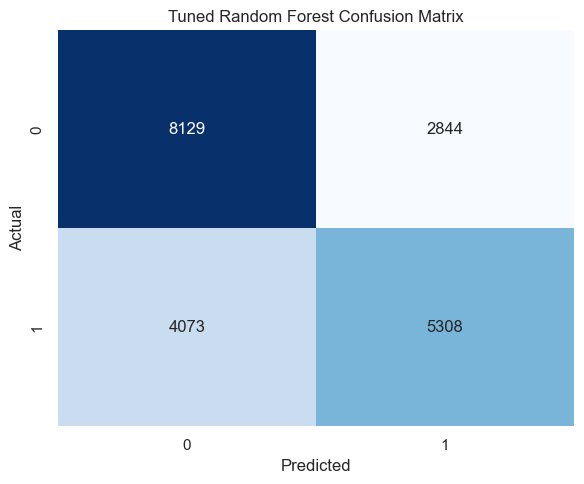

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Tuned Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.tight_layout()

plt.savefig("../images/tuned_random_forest_confusion_matrix.png", dpi=300)

plt.show()